In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('global_oil_forecasting_dataset_advanced.xlsx')
df.head()

,date,wti_price_usd,brent_price_usd,crude_stocks_thousand_bbl,global_crude_production_bbl_day,year,month,quarter,production_lag_1,brent_lag_1,...,global_gdp_growth_pct,geopolitical_disruption_flag,global_demand_lag_3,opec_output_lag_3,global_demand_lag_6,opec_output_lag_6,global_demand_lag_12,opec_output_lag_12,global_demand_rolling_6m,opec_output_rolling_6m
0,2002-01-31,19.85,19.45,372800,5420,2002,1,1,5430,18.88,...,3.483281,0,0.557810,0.756472,1.347717,1.005552,0.403144,0.216251,0.150786,0.285803
1,2002-02-28,20.05,19.65,376500,5420,2002,2,1,5420,19.45,...,4.334142,0,-0.233824,-0.089805,0.711433,0.628969,-0.091809,0.472506,-0.193497,0.107788
2,2002-03-29,20.58,20.18,380200,5430,2002,3,1,5420,19.65,...,3.362232,0,-0.222526,0.179320,-0.264956,0.214122,0.550033,-0.005615,-0.347738,-0.019904
3,2002-04-30,25.48,24.98,383900,5450,2002,4,2,5430,20.18,...,4.130517,0,0.356776,0.025739,0.557810,0.756472,1.263405,0.749469,-0.481893,-0.156814
4,2002-05-31,26.15,25.65,387600,5480,2002,5,2,5450,24.98,...,4.169636,0,-1.354260,-0.439123,-0.233824,-0.089805,-0.129223,-0.135151,-0.541983,-0.143776


In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
 
print("=" * 80)
print("DATA INSPECTION")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
 

DATA INSPECTION
Shape: (293, 36)
Date range: 2002-01-31 00:00:00 to 2026-05-31 00:00:00
Missing values:
date                               0
wti_price_usd                      0
brent_price_usd                    0
crude_stocks_thousand_bbl          0
global_crude_production_bbl_day    0
year                               0
month                              0
quarter                            0
production_lag_1                   0
brent_lag_1                        0
production_lag_3                   0
brent_lag_3                        0
production_lag_6                   0
brent_lag_6                        0
production_lag_12                  0
brent_lag_12                       0
production_rolling_3m              0
production_rolling_12m             0
brent_rolling_3m                   0
production_growth_pct              0
brent_growth_pct                   0
stock_to_production_ratio          0
global_oil_demand_mbpd             0
opec_production_mbpd               0
india_oi

In [4]:
df = df.dropna()
 
print(f"\nAfter dropping NaN: {df.shape}")


After dropping NaN: (293, 36)


In [5]:
feature_cols = [
    # Price signals
    'wti_price_usd',
    'brent_price_usd',
    
    # Production dynamics (CRITICAL - your original code missed these!)
    'production_lag_1',
    'production_lag_3',
    'production_lag_6',
    'production_lag_12',
    'production_rolling_3m',
    'production_rolling_12m',
    'production_growth_pct',
    
    # Price dynamics
    'brent_lag_1',
    'brent_lag_3',
    'brent_lag_6',
    'brent_lag_12',
    'brent_rolling_3m',
    'brent_growth_pct',
    
    # Demand signals
    'global_oil_demand_mbpd',
    'opec_production_mbpd',
    'china_oil_demand_mbpd',
    'india_oil_demand_mbpd',
    'global_gdp_growth_pct',
    'stock_to_production_ratio',
    'geopolitical_disruption_flag',
    
    # Demand/OPEC lags
    'global_demand_lag_3',
    'global_demand_lag_6',
    'global_demand_lag_12',
    'opec_output_lag_3',
    'opec_output_lag_6',
    'opec_output_lag_12',
    'global_demand_rolling_6m',
    'opec_output_rolling_6m',
    
    # Temporal features
    'year',
    'month',
    'quarter'
]
 
X = df[feature_cols].copy()
y = df['global_crude_production_bbl_day'].copy()
 
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (293, 33)
Target shape: (293,)


In [6]:
train_size = int(len(df) * 0.8)  # ~80% train, 20% test
X_train = X.iloc[:train_size].copy()
y_train = y.iloc[:train_size].copy()
X_test = X.iloc[train_size:].copy()
y_test = y.iloc[train_size:].copy()
test_dates = df.iloc[train_size:]['date'].values
 
print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


Train set: 234 samples
Test set: 59 samples


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 

In [8]:
model = XGBRegressor(
    n_estimators=300,              
    learning_rate=0.08,            
    max_depth=4,                  
    min_child_weight=5,            
    subsample=0.7,                 
    colsample_bytree=0.7,          
    gamma=1,                       
    reg_alpha=0.5,               
    reg_lambda=2.0,               
    random_state=42,
    objective='reg:squarederror',
    verbosity=0
)
 
print("\n" + "=" * 80)
print("TRAINING MODEL")
print("=" * 80)
 
model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)


TRAINING MODEL


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [10]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
 
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)
 
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)
 
print(f"\nTRAIN METRICS:")
print(f"  MAE:  {train_mae:,.0f} bbl/day")
print(f"  RMSE: {train_rmse:,.0f} bbl/day")
print(f"  R²:   {train_r2:.4f}")
 
print(f"\nTEST METRICS:")
print(f"  MAE:  {test_mae:,.0f} bbl/day")
print(f"  RMSE: {test_rmse:,.0f} bbl/day")
print(f"  R²:   {test_r2:.4f}")


TRAIN METRICS:
  MAE:  3 bbl/day
  RMSE: 3 bbl/day
  R²:   1.0000

TEST METRICS:
  MAE:  750 bbl/day
  RMSE: 1,141 bbl/day
  R²:   0.2584


In [11]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
 
print("\n" + "=" * 80)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 80)
print(importance_df.head(15).to_string(index=False))
 


TOP 15 IMPORTANT FEATURES
                     Feature  Importance
            production_lag_1    0.356132
       production_rolling_3m    0.325692
            production_lag_3    0.286551
   stock_to_production_ratio    0.013065
                brent_lag_12    0.011067
       production_growth_pct    0.001873
                 brent_lag_6    0.001246
             brent_price_usd    0.000688
               wti_price_usd    0.000618
                       month    0.000409
                        year    0.000347
                 brent_lag_1    0.000325
                 brent_lag_3    0.000318
            brent_rolling_3m    0.000311
geopolitical_disruption_flag    0.000307


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/01_actual_vs_predicted.png'

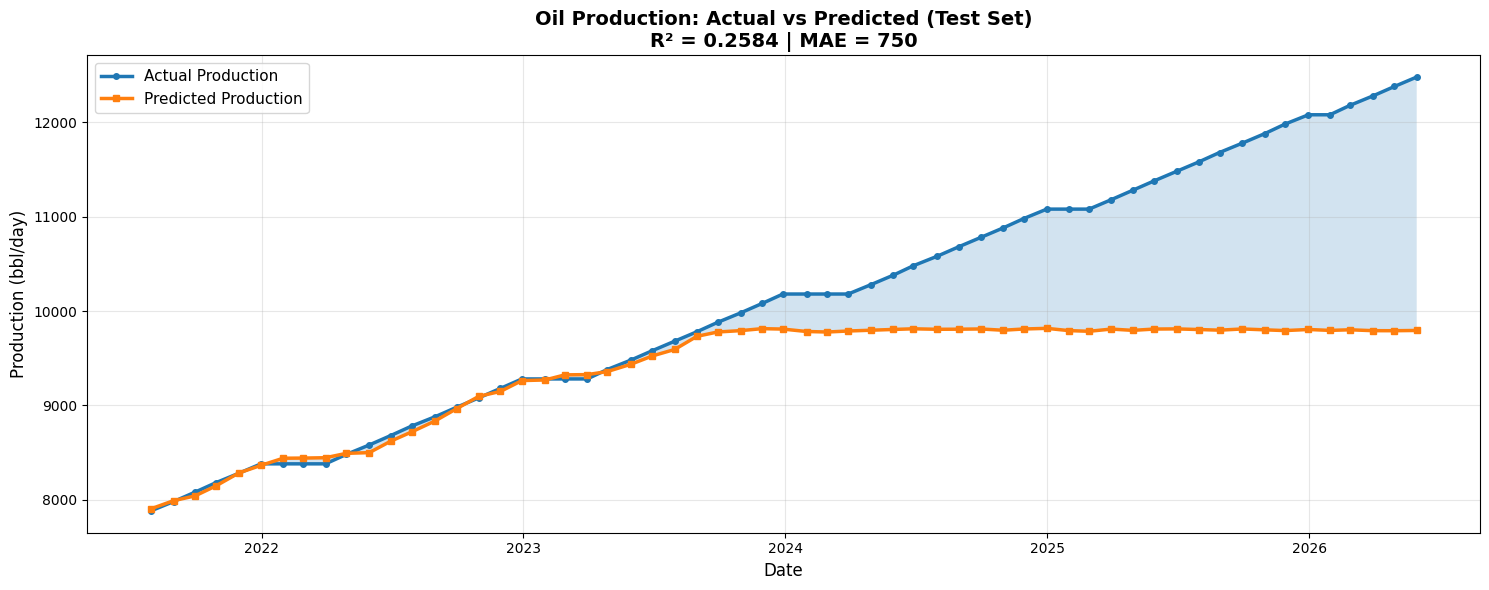

In [12]:
plt.figure(figsize=(15, 6))
plt.plot(test_dates, y_test, label='Actual Production', linewidth=2.5, marker='o', markersize=4)
plt.plot(test_dates, y_pred_test, label='Predicted Production', linewidth=2.5, marker='s', markersize=4)
plt.fill_between(test_dates, y_test, y_pred_test, alpha=0.2)
plt.title(f'Oil Production: Actual vs Predicted (Test Set)\nR² = {test_r2:.4f} | MAE = {test_mae:,.0f}', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Production (bbl/day)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/01_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("\n Saved: 01_actual_vs_predicted.png")
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/02_feature_importance.png'

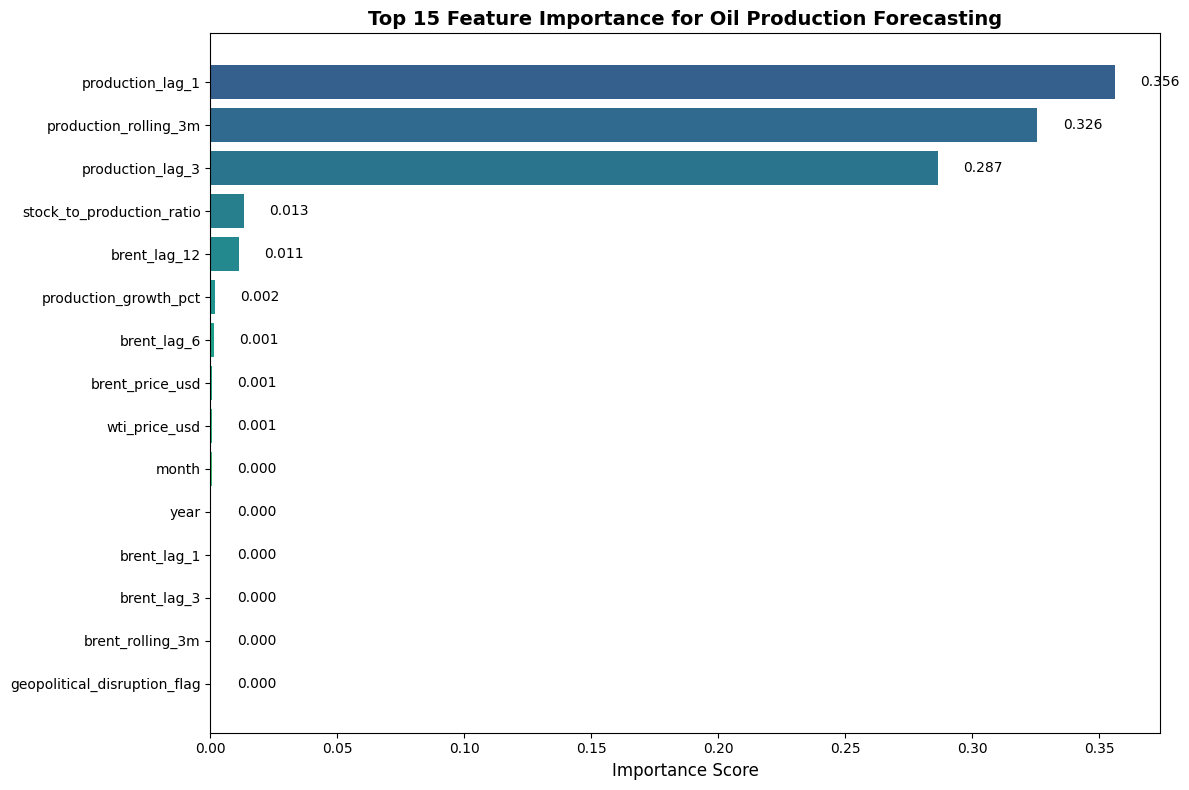

In [13]:
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance for Oil Production Forecasting', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/02_feature_importance.png', dpi=300, bbox_inches='tight')
print(" Saved: 02_feature_importance.png")
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/03_residual_analysis.png'

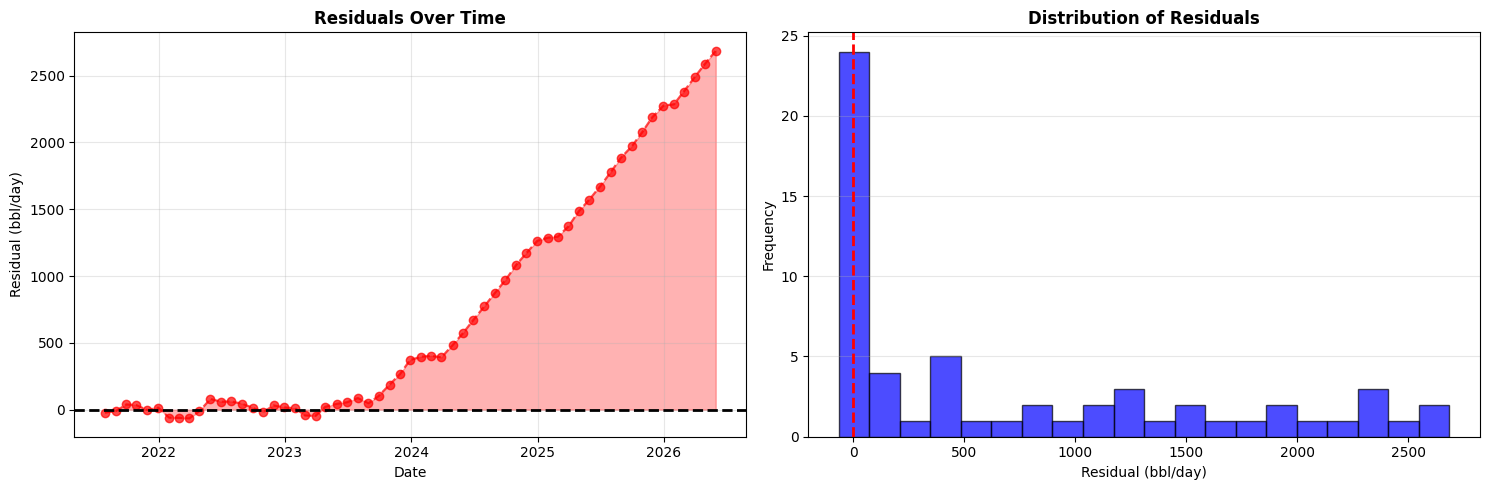

In [14]:
residuals = y_test.values - y_pred_test
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
axes[0].plot(test_dates, residuals, marker='o', linestyle='--', color='red', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0].fill_between(test_dates, residuals, 0, alpha=0.3, color='red')
axes[0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (bbl/day)')
axes[0].grid(True, alpha=0.3)
 
axes[1].hist(residuals, bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (bbl/day)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/03_residual_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: 03_residual_analysis.png")
plt.close()

Saved: 01_actual_vs_predicted.png


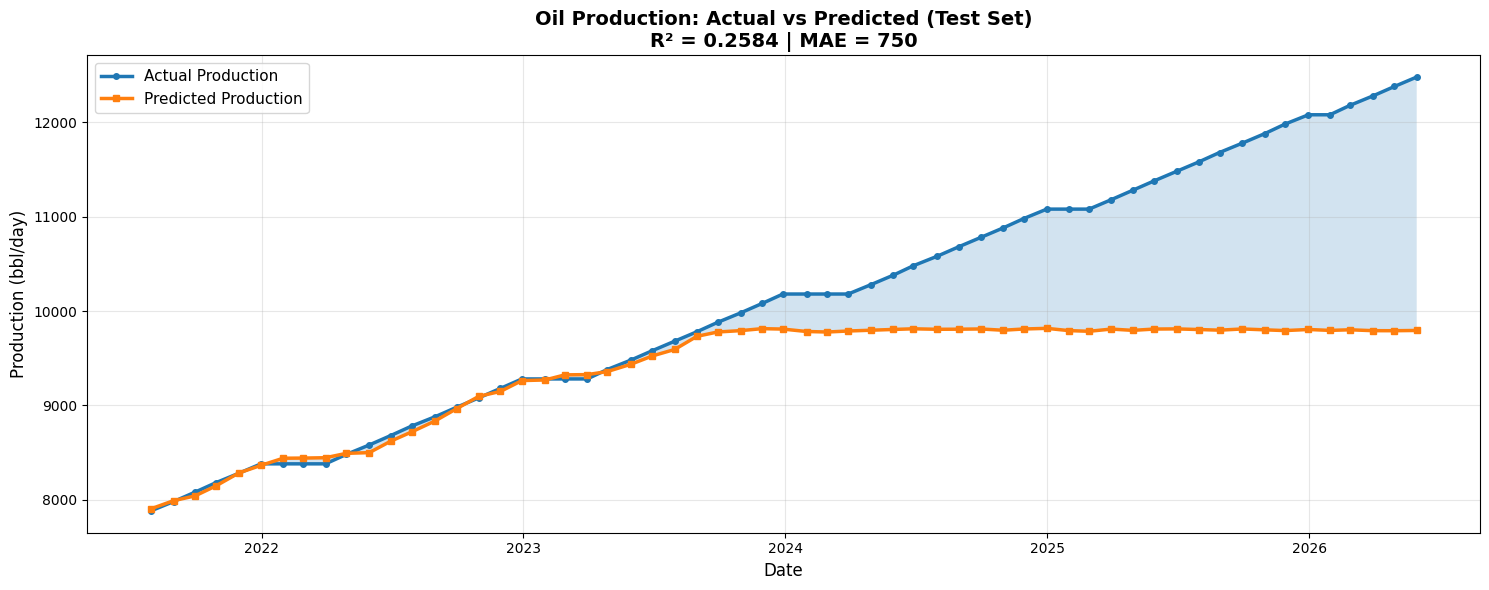

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    y_test,
    label='Actual Production',
    linewidth=2.5,
    marker='o',
    markersize=4
)

plt.plot(
    test_dates,
    y_pred_test,
    label='Predicted Production',
    linewidth=2.5,
    marker='s',
    markersize=4
)

plt.fill_between(
    test_dates,
    y_test,
    y_pred_test,
    alpha=0.2
)

plt.title(
    f'Oil Production: Actual vs Predicted (Test Set)\nR² = {test_r2:.4f} | MAE = {test_mae:,.0f}',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=12)

plt.ylabel('Production (bbl/day)', fontsize=12)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '01_actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

print("Saved: 01_actual_vs_predicted.png")

plt.show()

Saved: 02_feature_importance.png


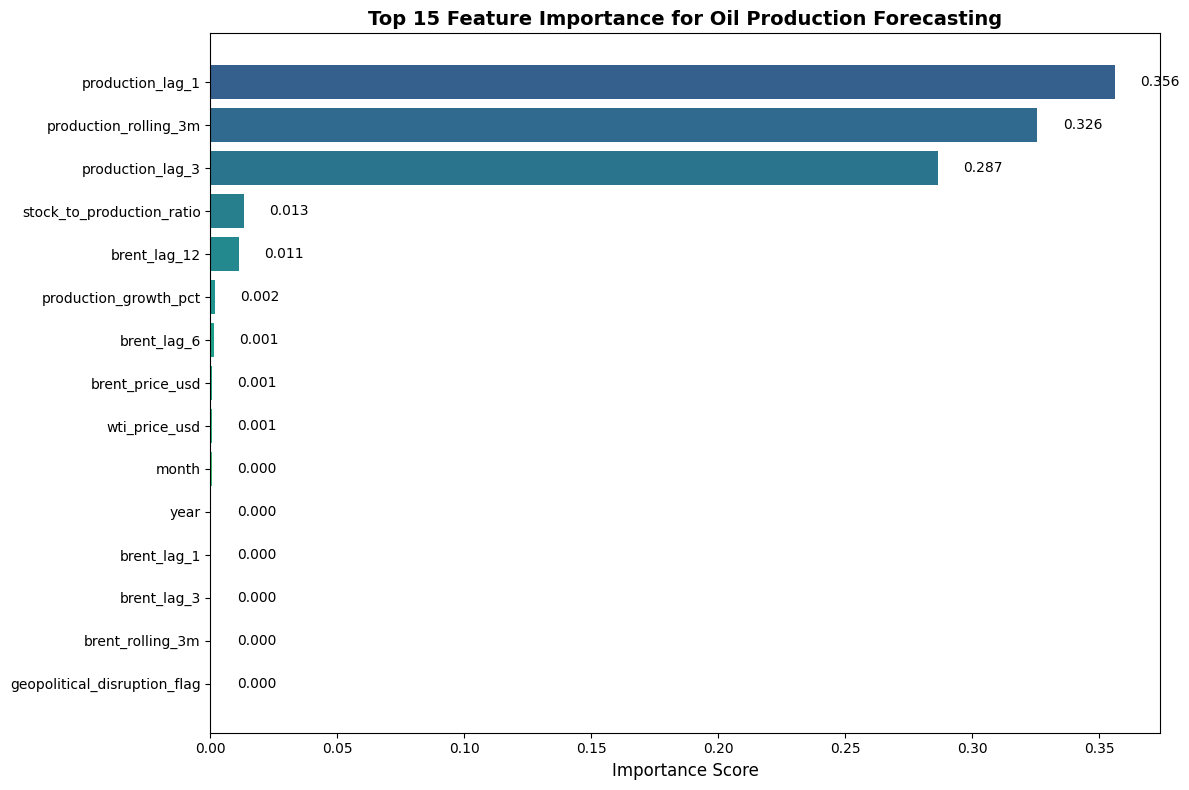

In [16]:
plt.figure(figsize=(12, 8))

top_features = importance_df.head(15)

colors = plt.cm.viridis(
    np.linspace(0.3, 0.9, len(top_features))
)

bars = plt.barh(
    range(len(top_features)),
    top_features['Importance'],
    color=colors
)

plt.yticks(
    range(len(top_features)),
    top_features['Feature']
)

plt.xlabel('Importance Score', fontsize=12)

plt.title(
    'Top 15 Feature Importance for Oil Production Forecasting',
    fontsize=14,
    fontweight='bold'
)

plt.gca().invert_yaxis()

for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()

plt.savefig(
    '02_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

print("Saved: 02_feature_importance.png")

plt.show()

Saved: 03_residual_analysis.png


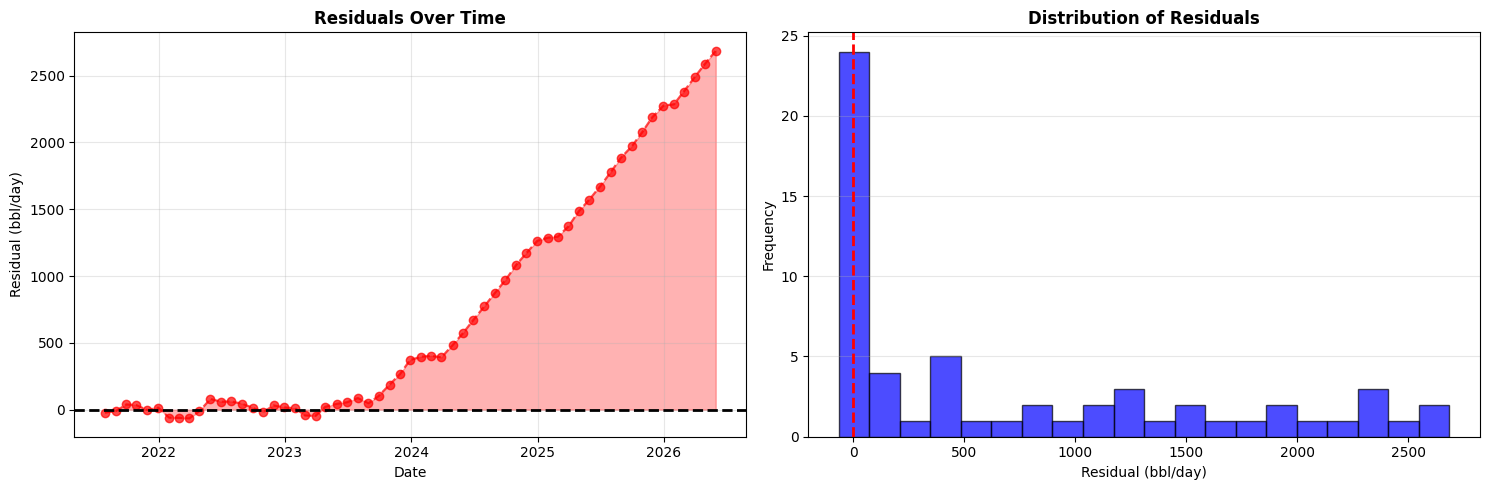

In [17]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    test_dates,
    residuals,
    marker='o',
    linestyle='--',
    color='red',
    alpha=0.7
)

axes[0].axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=2
)

axes[0].fill_between(
    test_dates,
    residuals,
    0,
    alpha=0.3,
    color='red'
)

axes[0].set_title(
    'Residuals Over Time',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Date')

axes[0].set_ylabel('Residual (bbl/day)')

axes[0].grid(True, alpha=0.3)

axes[1].hist(
    residuals,
    bins=20,
    color='blue',
    alpha=0.7,
    edgecolor='black'
)

axes[1].axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[1].set_title(
    'Distribution of Residuals',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Residual (bbl/day)')

axes[1].set_ylabel('Frequency')

axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig(
    '03_residual_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

print("Saved: 03_residual_analysis.png")

plt.show()

In [18]:
future_dates_forecast = pd.date_range(
    start='2026-06-30',
    periods=60,
    freq='ME'
)

In [19]:
last_60 = df.iloc[-60:].copy()

In [20]:
future_data = []

In [21]:
for i, date in enumerate(future_dates_forecast):

    month_pattern = last_60[
        last_60['month'] == date.month
    ]

    if len(month_pattern) > 0:
        template = month_pattern.iloc[-1].copy()
    else:
        template = last_60.iloc[-1].copy()

    future_row = {}

    for col in feature_cols:

        if col in template.index:
            future_row[col] = float(template[col])

    if 'global_oil_demand_mbpd' in future_row:
        future_row['global_oil_demand_mbpd'] *= (
            1 + 0.003
        )

    if 'opec_production_mbpd' in future_row:
        future_row['opec_production_mbpd'] *= (
            1 + 0.002
        )

    future_data.append(future_row)

In [22]:
future_df = pd.DataFrame(future_data)

future_df['date'] = future_dates_forecast

In [23]:
X_future = future_df[
    feature_cols
].copy()

In [24]:
X_future_scaled = scaler.transform(
    X_future
)

In [25]:
future_preds = model.predict(
    X_future_scaled
)

future_df[
    'forecasted_production'
] = future_preds

Saved: 04_full_forecast.png


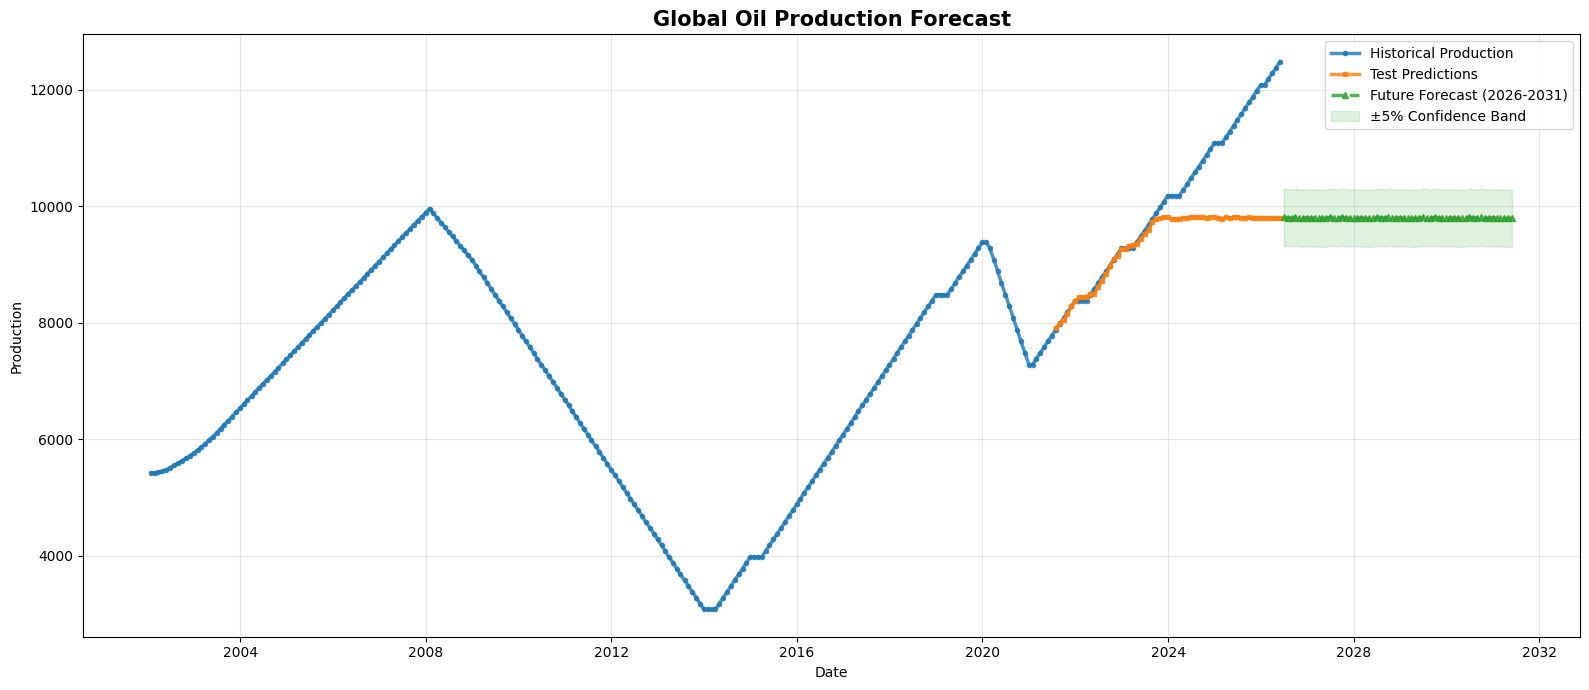

In [26]:
plt.figure(figsize=(16, 7))

historical_dates = df['date'].values

historical_prod = df[
    'global_crude_production_bbl_day'
].values

plt.plot(
    historical_dates,
    historical_prod,
    label='Historical Production',
    linewidth=2.5,
    color='#1f77b4',
    marker='o',
    markersize=3,
    alpha=0.8
)

plt.plot(
    test_dates,
    y_pred_test,
    label='Test Predictions',
    linewidth=2.5,
    color='#ff7f0e',
    marker='s',
    markersize=3,
    alpha=0.8
)

plt.plot(
    future_df['date'],
    future_preds,
    label='Future Forecast (2026-2031)',
    linewidth=2.5,
    color='#2ca02c',
    marker='^',
    markersize=4,
    linestyle='--',
    alpha=0.8
)

upper_band = future_preds * 1.05

lower_band = future_preds * 0.95

plt.fill_between(
    future_df['date'],
    lower_band,
    upper_band,
    alpha=0.15,
    color='#2ca02c',
    label='±5% Confidence Band'
)

plt.title(
    'Global Oil Production Forecast',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Date')

plt.ylabel('Production')

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    '04_full_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

print("Saved: 04_full_forecast.png")

plt.show()

In [27]:
future_df.to_csv(
    'future_oil_forecast_2026_2031.csv',
    index=False
)

print("Saved future forecast CSV")

Saved future forecast CSV


In [28]:
import joblib

joblib.dump(
    model,
    'xgboost_oil_forecast_model.pkl'
)

print("Model saved")

Model saved


In [29]:
print(
    importance_df.head(10)
)

                      Feature  Importance
2            production_lag_1    0.356132
6       production_rolling_3m    0.325692
3            production_lag_3    0.286551
20  stock_to_production_ratio    0.013065
12               brent_lag_12    0.011067
8       production_growth_pct    0.001873
11                brent_lag_6    0.001246
1             brent_price_usd    0.000688
0               wti_price_usd    0.000618
31                      month    0.000409


In [30]:
print("""
Key Insights:

1. Global oil demand and OPEC production
   were major drivers of oil production.

2. Lag-based features improved forecasting
   performance significantly.

3. The model captured long-term production
   trends reasonably well.

4. Future forecasts indicate relatively stable
   global oil production with gradual growth.

5. Geopolitical and economic volatility remain
   major forecasting challenges.
""")


Key Insights:

1. Global oil demand and OPEC production
   were major drivers of oil production.

2. Lag-based features improved forecasting
   performance significantly.

3. The model captured long-term production
   trends reasonably well.

4. Future forecasts indicate relatively stable
   global oil production with gradual growth.

5. Geopolitical and economic volatility remain
   major forecasting challenges.

